In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Input Data

In [2]:
data = pd.read_csv("/content/Data/Zomato Dataset.csv")

In [3]:
data.head(10)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41
5,0x3af3,MUMRES15DEL03,29.0,4.5,19.176269,72.836721,19.266269,72.926721,02-04-2022,20:25,20:35,Sandstorms,Jam,2,Buffet,electric_scooter,1.0,No,Metropolitian,20
6,0x3aab,MYSRES01DEL01,35.0,4.0,12.311072,76.654878,12.351072,76.694878,01-03-2022,14:55,15:10,Windy,High,1,Meal,scooter,1.0,No,Metropolitian,33
7,0x689b,PUNERES20DEL01,33.0,4.2,18.592718,73.773572,18.702718,73.883572,16-03-2022,20:30,20:40,Sandstorms,Jam,2,Snack,motorcycle,1.0,No,Metropolitian,40
8,0x6f67,HYDRES14DEL01,34.0,4.9,17.426228,78.407495,17.496228,78.477495,20-03-2022,20:40,20:50,Cloudy,Jam,0,Snack,motorcycle,NaN,No,Metropolitian,41
9,0xc9cf,KOLRES15DEL03,21.0,4.7,22.552672,88.352885,22.582672,88.382885,15-02-2022,21:15,21:30,Windy,Jam,0,Meal,motorcycle,1.0,No,Urban,15


## Data Preparation

Membuat kolom baru yang menghitung jarak dari restoran ke titik pengantaran menggunakan rumus Haversine

In [4]:
def hitung_haversine(lat1, lon1, lat2, lon2):
    R = 6371.0

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # Rumus Haversine
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))

    jarak = R * c
    return np.round(jarak, 2)

In [5]:
data['Distance_km'] = hitung_haversine(
    data['Restaurant_latitude'],
    data['Restaurant_longitude'],
    data['Delivery_location_latitude'],
    data['Delivery_location_longitude']
)

In [6]:
data.head(10)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min),Distance_km
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,...,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46,10.28
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,...,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23,6.24
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,...,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21,13.79
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,...,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20,2.93
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,...,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41,19.40
5,0x3af3,MUMRES15DEL03,29.0,4.5,19.176269,72.836721,19.266269,72.926721,02-04-2022,20:25,...,Sandstorms,Jam,2,Buffet,electric_scooter,1.0,No,Metropolitian,20,13.76
6,0x3aab,MYSRES01DEL01,35.0,4.0,12.311072,76.654878,12.351072,76.694878,01-03-2022,14:55,...,Windy,High,1,Meal,scooter,1.0,No,Metropolitian,33,6.22
7,0x689b,PUNERES20DEL01,33.0,4.2,18.592718,73.773572,18.702718,73.883572,16-03-2022,20:30,...,Sandstorms,Jam,2,Snack,motorcycle,1.0,No,Metropolitian,40,16.85
8,0x6f67,HYDRES14DEL01,34.0,4.9,17.426228,78.407495,17.496228,78.477495,20-03-2022,20:40,...,Cloudy,Jam,0,Snack,motorcycle,NaN,No,Metropolitian,41,10.76
9,0xc9cf,KOLRES15DEL03,21.0,4.7,22.552672,88.352885,22.582672,88.382885,15-02-2022,21:15,...,Windy,Jam,0,Meal,motorcycle,1.0,No,Urban,15,4.54


## Pilih Variabel

Akan diambil beberapa peubah yang nantinya akan digunakan

In [7]:
variabel = [
    'Time_taken (min)',
    'Delivery_person_Age',
    'Delivery_person_Ratings',
    'Time_Orderd',
    'Weather_conditions',
    'Road_traffic_density',
    'Type_of_order',
    'Type_of_vehicle',
    'multiple_deliveries',
    'Festival',
    'City',
    'Distance_km'
]

df = data[variabel].copy()

In [8]:
df.head(10)

,Time_taken (min),Delivery_person_Age,Delivery_person_Ratings,Time_Orderd,Weather_conditions,Road_traffic_density,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Distance_km
0,46,36.0,4.2,21:55,Fog,Jam,Snack,motorcycle,3.0,No,Metropolitian,10.28
1,23,21.0,4.7,14:55,Stormy,High,Meal,motorcycle,1.0,No,Metropolitian,6.24
2,21,23.0,4.7,17:30,Sandstorms,Medium,Drinks,scooter,1.0,No,Metropolitian,13.79
3,20,34.0,4.3,09:20,Sandstorms,Low,Buffet,motorcycle,0.0,No,Metropolitian,2.93
4,41,24.0,4.7,19:50,Fog,Jam,Snack,scooter,1.0,No,Metropolitian,19.40
5,20,29.0,4.5,20:25,Sandstorms,Jam,Buffet,electric_scooter,1.0,No,Metropolitian,13.76
6,33,35.0,4.0,14:55,Windy,High,Meal,scooter,1.0,No,Metropolitian,6.22
7,40,33.0,4.2,20:30,Sandstorms,Jam,Snack,motorcycle,1.0,No,Metropolitian,16.85
8,41,34.0,4.9,20:40,Cloudy,Jam,Snack,motorcycle,NaN,No,Metropolitian,10.76
9,15,21.0,4.7,21:15,Windy,Jam,Meal,motorcycle,1.0,No,Urban,4.54


## Data Understanding

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Time_taken (min)         45584 non-null  int64  
 1   Delivery_person_Age      43730 non-null  float64
 2   Delivery_person_Ratings  43676 non-null  float64
 3   Time_Orderd              43853 non-null  object 
 4   Weather_conditions       44968 non-null  object 
 5   Road_traffic_density     44983 non-null  object 
 6   Type_of_order            45584 non-null  object 
 7   Type_of_vehicle          45584 non-null  object 
 8   multiple_deliveries      44591 non-null  float64
 9   Festival                 45356 non-null  object 
 10  City                     44384 non-null  object 
 11  Distance_km              45584 non-null  float64
dtypes: float64(4), int64(1), object(7)
memory usage: 4.2+ MB


In [10]:
df.shape

(45584, 12)

In [11]:
df.describe()

,Time_taken (min),Delivery_person_Age,Delivery_person_Ratings,multiple_deliveries,Distance_km
count,45584.000000,43730.000000,43676.000000,44591.000000,45584.000000
mean,26.293963,29.566911,4.633774,0.744635,99.321338
std,9.384298,5.815064,0.334744,0.572510,1099.839158
min,10.000000,15.000000,1.000000,0.000000,1.470000
25%,19.000000,25.000000,4.500000,0.000000,4.660000
50%,26.000000,30.000000,4.700000,1.000000,9.260000
75%,32.000000,35.000000,4.900000,1.000000,13.760000
max,54.000000,50.000000,6.000000,3.000000,19692.670000


# Data Cleaning

## Data Duplikat

In [12]:
df.duplicated().sum()

np.int64(0)

- Tidak terdapat data duplikat

## Missing Value

In [13]:
df.isna().sum()

,0
Time_taken (min),0
Delivery_person_Age,1854
Delivery_person_Ratings,1908
Time_Orderd,1731
Weather_conditions,616
Road_traffic_density,601
Type_of_order,0
Type_of_vehicle,0
multiple_deliveries,993
Festival,228


- Untuk missing value pada peubah numerik ada:
  > Delivery Person Age

  > Delivery Person Ratings

  > Multiple Deliveries
- Untuk missing value pada peubah kategorik ada:
  > Weather Conditions

  > Road Traffic Density

  > Festival

  > City
- Dan ada missing value pada data bertipe waktu yaitu `Time_Orderd`

### Handling Missing Value

#### Numerik

In [14]:
kolom_numerik = ['Delivery_person_Age', 'Delivery_person_Ratings', 'multiple_deliveries']
for i in kolom_numerik:
    nilai_median = df[i].median()
    df[i] = df[i].fillna(nilai_median)
    print(f"Imputasi '{i}' dengan median = {nilai_median}")


Imputasi 'Delivery_person_Age' dengan median = 30.0
Imputasi 'Delivery_person_Ratings' dengan median = 4.7
Imputasi 'multiple_deliveries' dengan median = 1.0


#### Kategorik

In [15]:
kolom_kategorik = ['Weather_conditions', 'Road_traffic_density', 'Festival', 'City']
for i in kolom_kategorik:
    nilai_modus = df[i].mode()[0]
    df[i] = df[i].fillna(nilai_modus)
    print(f"Imputasi '{i}' dengan modus = '{nilai_modus}'")


Imputasi 'Weather_conditions' dengan modus = 'Fog'
Imputasi 'Road_traffic_density' dengan modus = 'Low'
Imputasi 'Festival' dengan modus = 'No'
Imputasi 'City' dengan modus = 'Metropolitian'


#### `Time_Orderd`

In [16]:
df.dropna(subset=['Time_Orderd'], inplace=True)

### Pengecekan ulang missing value

In [17]:
df.isna().sum()

,0
Time_taken (min),0
Delivery_person_Age,0
Delivery_person_Ratings,0
Time_Orderd,0
Weather_conditions,0
Road_traffic_density,0
Type_of_order,0
Type_of_vehicle,0
multiple_deliveries,0
Festival,0


Data sudah aman dari missing value

# EDA

## Statistik Deskriptif

### Numerik

In [18]:
df.describe().round(1)

,Time_taken (min),Delivery_person_Age,Delivery_person_Ratings,multiple_deliveries,Distance_km
count,43853.0,43853.0,43853.0,43853.0,43853.0
mean,26.3,29.6,4.6,0.7,27.2
std,9.4,5.7,0.3,0.6,303.1
min,10.0,20.0,2.5,0.0,1.5
25%,19.0,25.0,4.5,0.0,4.7
50%,26.0,30.0,4.7,1.0,9.2
75%,32.0,35.0,4.9,1.0,13.7
max,54.0,39.0,5.0,3.0,6884.7


### Kategorik

In [19]:
for i in df.select_dtypes(include=['object']).columns:
  print (f"{df[i].value_counts()}")
  print ("-----------------------------------")

Time_Orderd
21:55          461
17:55          456
0.833333333    449
22:20          448
21:35          446
              ... 
12:25           57
14:15           56
0.666666667     53
13:20           52
16:30           51
Name: count, Length: 176, dtype: int64
-----------------------------------
Weather_conditions
Fog           7475
Stormy        7400
Cloudy        7336
Sandstorms    7284
Windy         7251
Sunny         7107
Name: count, dtype: int64
-----------------------------------
Road_traffic_density
Low       15061
Jam       13796
Medium    10676
High       4320
Name: count, dtype: int64
-----------------------------------
Type_of_order
Snack     11088
Meal      11016
Drinks    10896
Buffet    10853
Name: count, dtype: int64
-----------------------------------
Type_of_vehicle
motorcycle          25627
scooter             14692
electric_scooter     3534
Name: count, dtype: int64
-----------------------------------
Festival
No     42996
Yes      857
Name: count, dtype: int64
-----

## Data Distribution

### Numerik

In [20]:
def check_plot(df, variable):
    plt.figure(figsize=(16, 4))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df[variable], bins=30)
    plt.title(f"Histogram {variable}")

    # Box plot
    plt.subplot(1, 2, 2)
    sns.boxplot(y = df[variable])
    plt.title(f"Box Plot {variable}")

    plt.show()

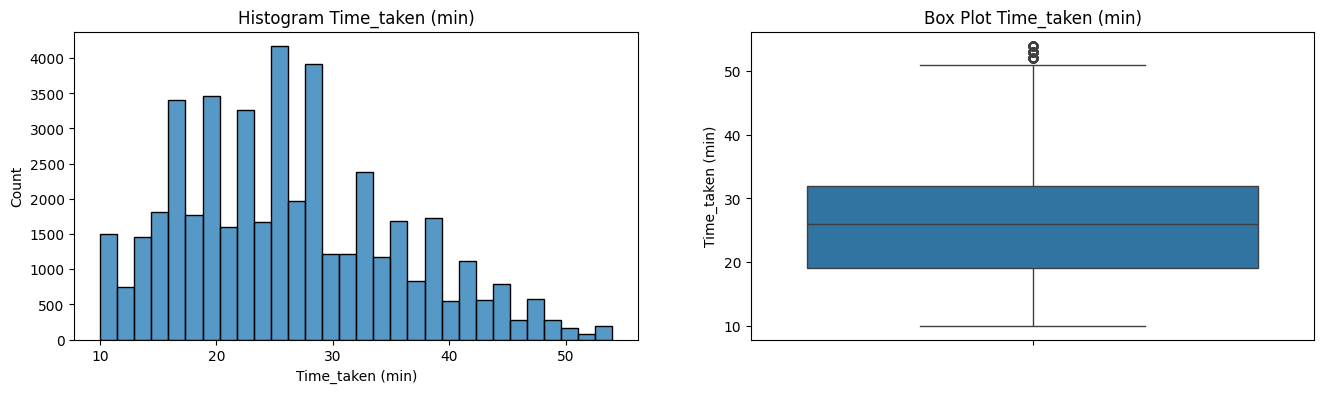

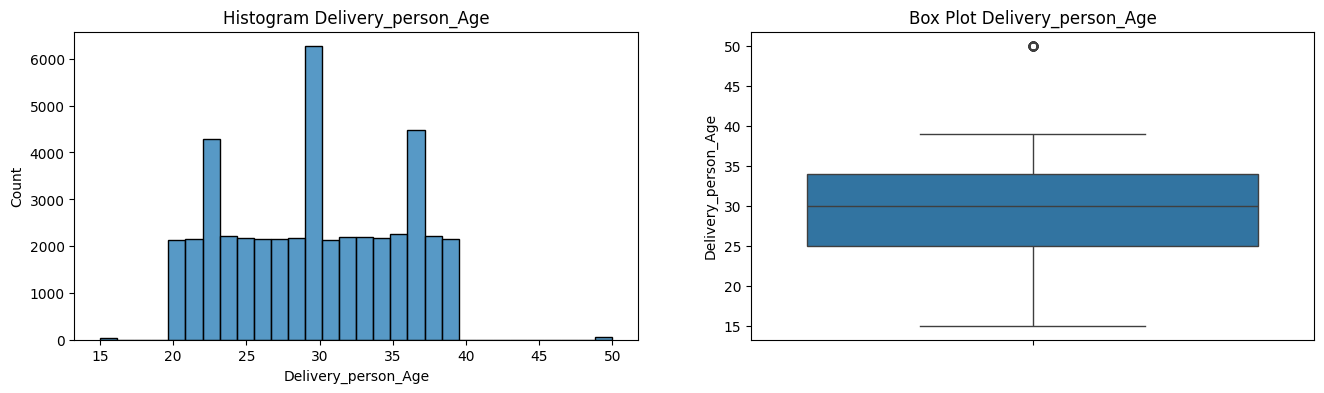

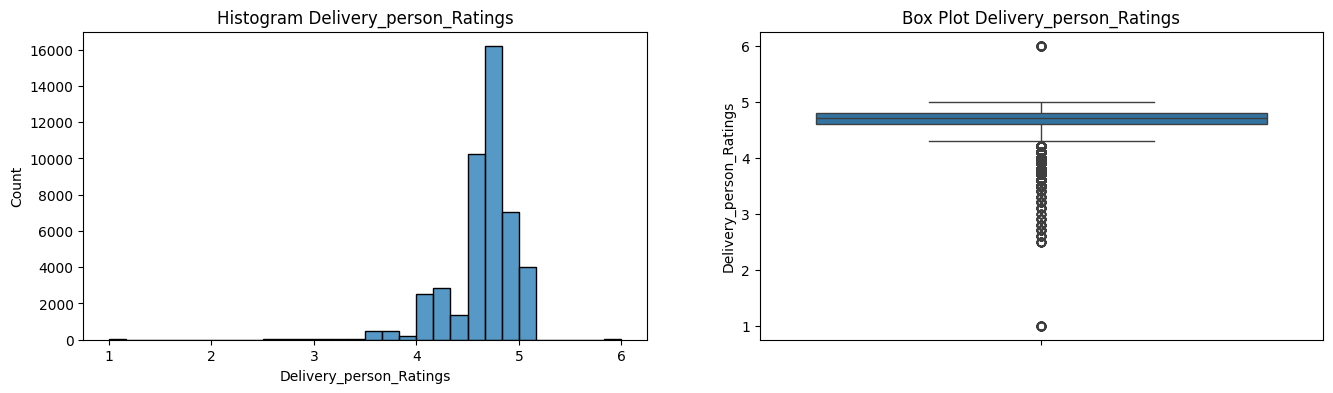

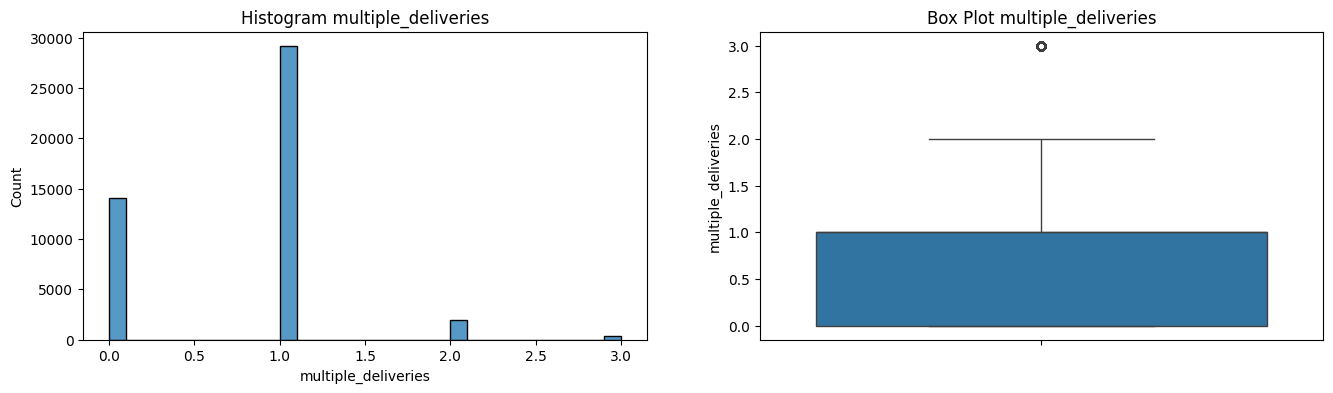

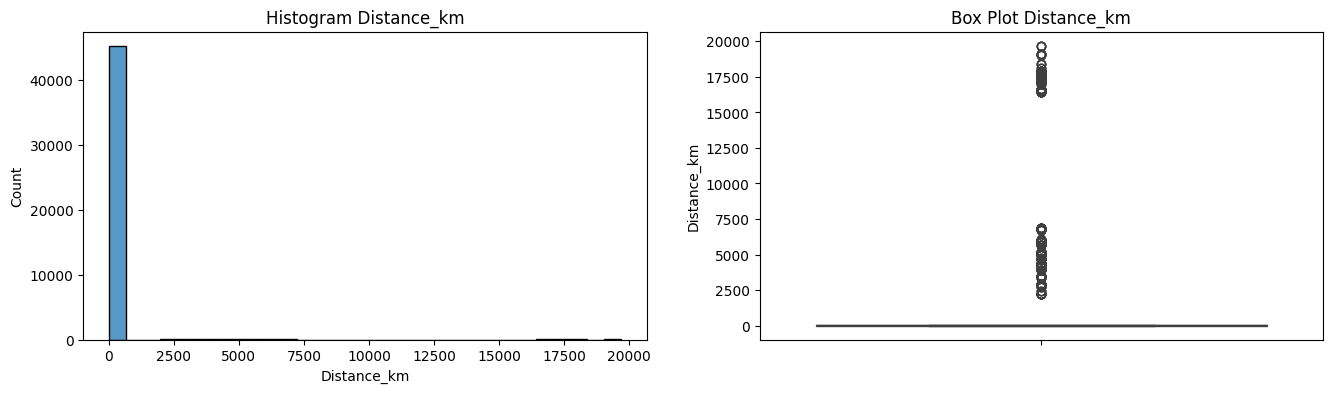

In [24]:
for i in df.select_dtypes(include = ['number']).columns:
  check_plot(df, i)

Ada keanehan pada kolom `Distance_km`, akan dilakukan pengecekan apakah ini memang nilai sebenarnya atau error dari data/error perhitungan.

In [21]:
cek_aneh = df[df['Distance_km'] > 50]
print(cek_aneh[['Distance_km', 'Time_taken (min)', 'Type_of_vehicle']])

       Distance_km  Time_taken (min) Type_of_vehicle
83         6048.63                15         scooter
274        6047.92                31         scooter
1082       3464.08                29      motorcycle
1774       5168.52                29      motorcycle
1967       5013.59                19      motorcycle
...            ...               ...             ...
43851      3454.52                24      motorcycle
44042      3377.65                27         scooter
44631      2230.11                21      motorcycle
44924      4423.28                15      motorcycle
45173      5895.02                34      motorcycle

[156 rows x 3 columns]


Secara hasil pengecekan, **tidak masuk akal**. Tidak mungkin ada scooter bisa nganter makanan dengan jarak ribuan kilo hanya butuh waktu 15 menit. Dan total keanehan ini ada 150-an row. Karena secara baris tidak terlalu banyak, maka saya memutuskan drop barisnya saja.

In [22]:
# Drop Anomali
df_clean = df[df['Distance_km'] <= 50].copy()

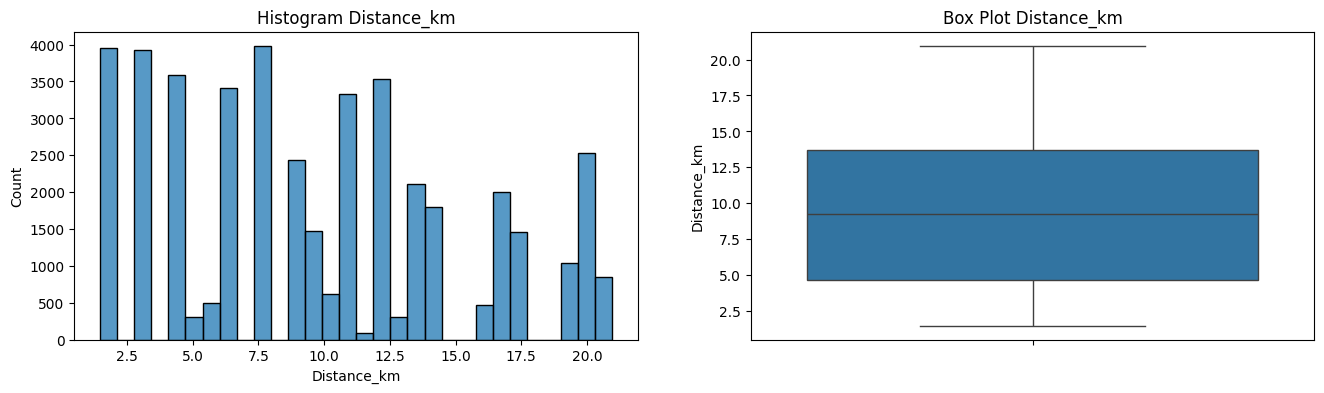

In [23]:
plt.figure(figsize=(16, 4))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(df_clean['Distance_km'], bins=30)
plt.title(f"Histogram Distance_km")

# Box plot
plt.subplot(1, 2, 2)
sns.boxplot(y = df_clean['Distance_km'])
plt.title(f"Box Plot Distance_km")

plt.show()

Hasil plot jadi lebih jelas dan interpretasinya jadi lebih masuk akal.

### Kategorik

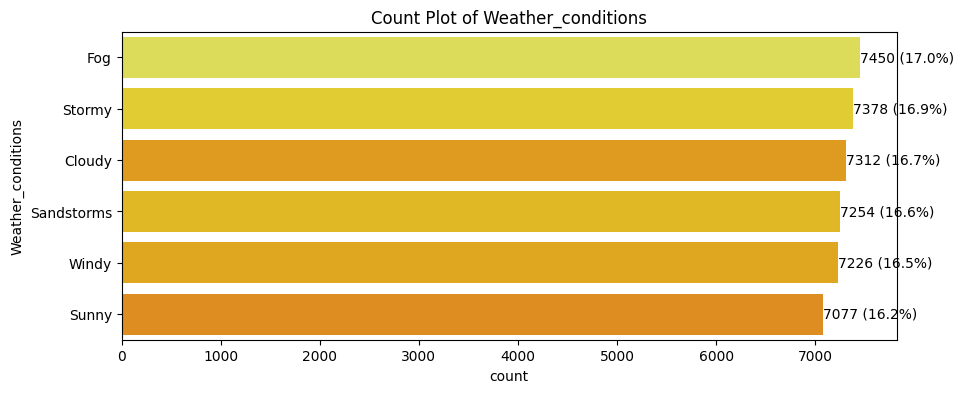

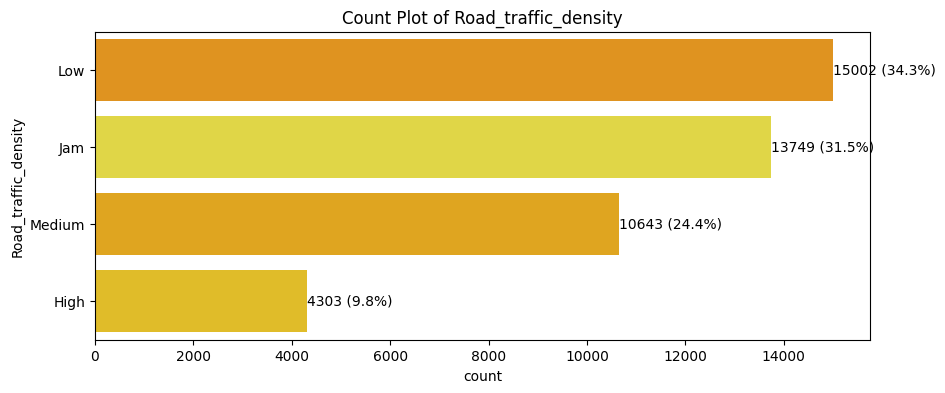

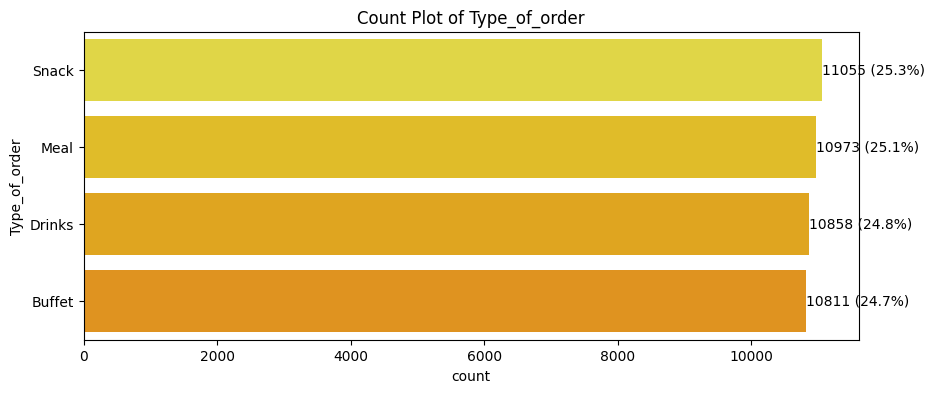

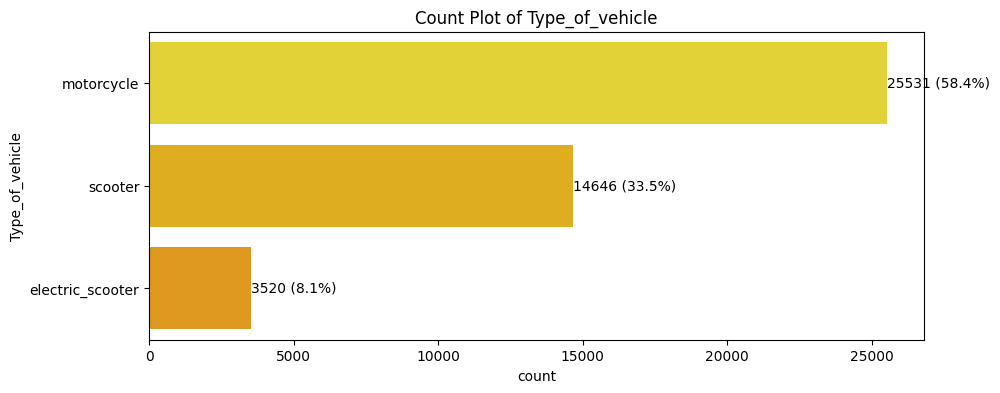

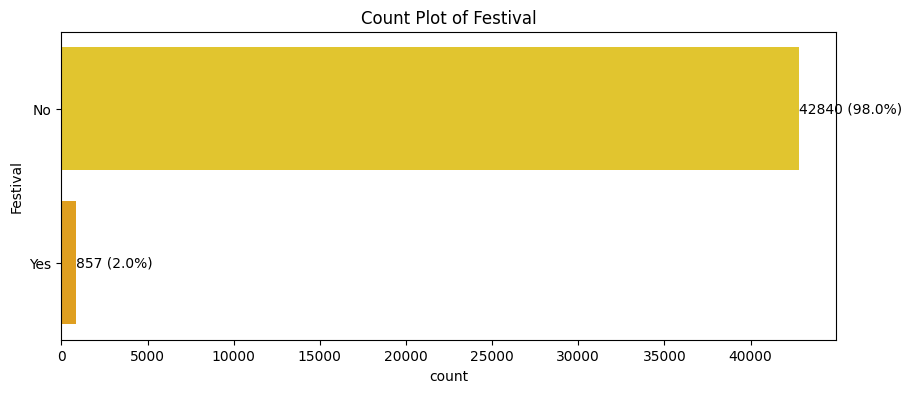

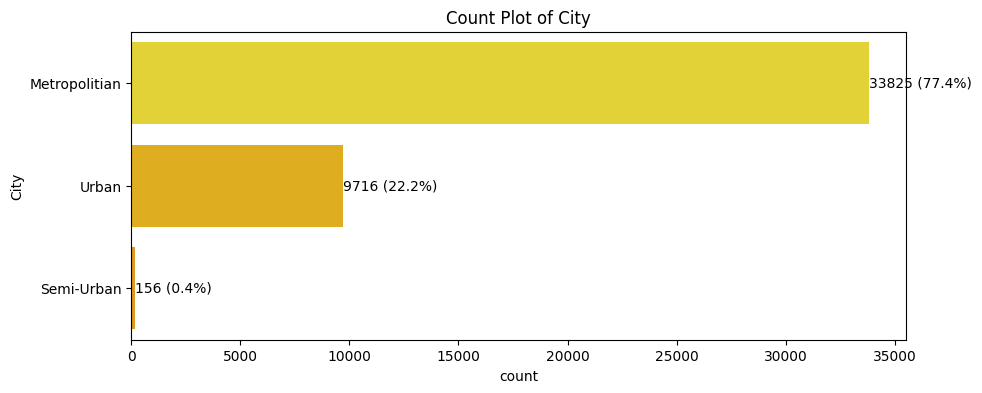

In [24]:
kolom_kategorik_2 = ['Weather_conditions', 'Road_traffic_density', 'Type_of_order', 'Type_of_vehicle', 'Festival', 'City']
for i in kolom_kategorik_2:
  plt.figure(figsize=(10,4))

  order_desc = df_clean[i].value_counts().index.tolist()
  ax = sns.countplot(data=df_clean, y=df_clean[i], order=order_desc, hue=df_clean[i], palette="Wistia", legend=False)

  for p in ax.patches:
    w = p.get_width()
    pos = p.get_width()
    y = p.get_y() + p.get_height()/2
    pct = 100 * w / len(df_clean[i])
    plt.text(pos, y, f"{int(w)} ({pct:.1f}%)", ha="left", va="center", color="black", fontsize=10)

  plt.title(f"Count Plot of {i}")
  plt.show()

## Correlation Heatmap

In [25]:
corr_data = pd.concat([df_clean.select_dtypes(include = ['number'])])
corr_data = corr_data.corr()

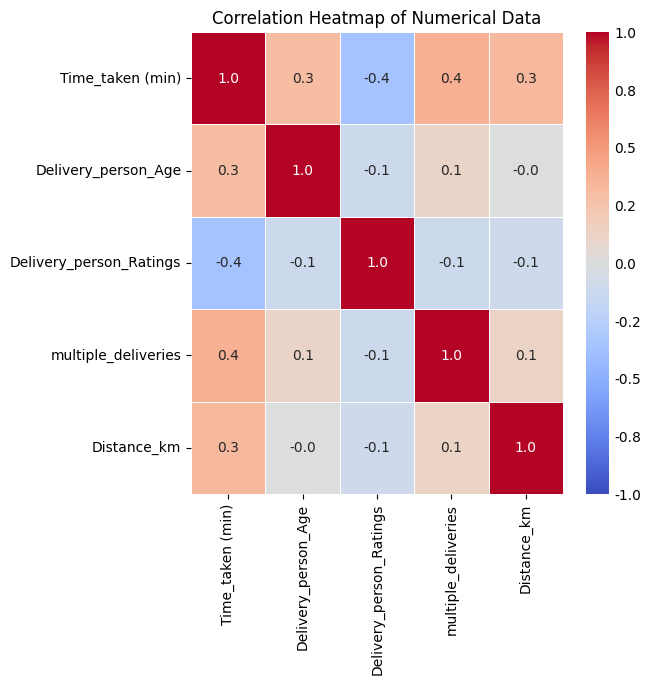

In [26]:
plt.figure(figsize=(6, 6))
ax = sns.heatmap(corr_data, annot=True, cmap='coolwarm', fmt=".1f", vmin = -1, vmax= 1, linewidths=0.5, cbar_kws={'format': '%.1f'} )
ax.collections[0].colorbar.ax.tick_params(size=0)
plt.title("Correlation Heatmap of Numerical Data")
plt.show()

Bila melihat dari heatmap diatas, ada 2 variabel dengan nilai korelasi tertinggi dengan `Time_taken` adalah `multiple_deliveries` dengan nilai korelasi 0.4 dan berkorelasi positif, dan ada `Delivery_person_Ratings` yang berkorelasi negatif (-0.4).

# Analisis Faktor Penentu Waktu Pengiriman Zomato

In [27]:
# Rata-rata waktu pengiriman berdasarkan tingkat kemacetan
print(df_clean.groupby('Road_traffic_density')['Time_taken (min)'].mean().sort_values(ascending=False))

Road_traffic_density
Jam       31.161612
High      27.202882
Medium    26.721695
Low       21.278963
Name: Time_taken (min), dtype: float64


In [28]:
# Rata-rata waktu pengiriman berdasarkan cuaca
print(df_clean.groupby('Weather_conditions')['Time_taken (min)'].mean().sort_values(ascending=False))

Weather_conditions
Fog           28.942013
Cloudy        28.941056
Windy         26.111818
Sandstorms    25.896057
Stormy        25.856330
Sunny         21.843154
Name: Time_taken (min), dtype: float64


In [29]:
# Rata-rata waktu tempuh dan jarak berdasarkan kendaraan
print(df_clean.groupby('Type_of_vehicle')[['Time_taken (min)', 'Distance_km']].mean())

                  Time_taken (min)  Distance_km
Type_of_vehicle                                
electric_scooter         24.424716     9.736199
motorcycle               27.603972     9.707446
scooter                  24.470094     9.778125


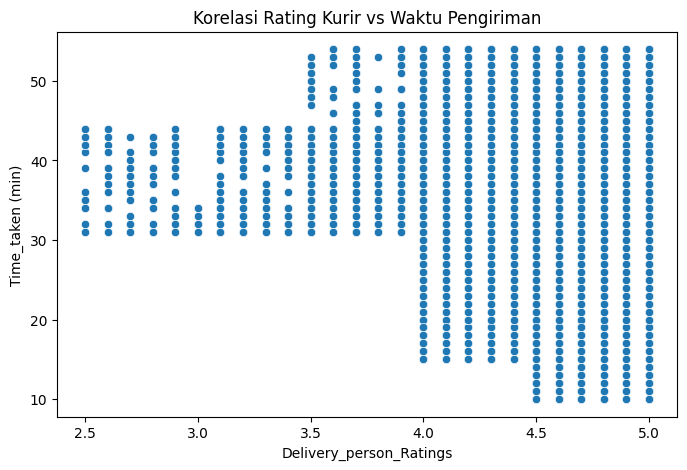

In [30]:
plt.figure(figsize=(8,5))
sns.scatterplot(x = 'Delivery_person_Ratings', y = 'Time_taken (min)', data = df_clean)
plt.title('Korelasi Rating Kurir vs Waktu Pengiriman')
plt.show()

# Ekspor Data Clean

## Ubah data date

In [31]:
df_clean['Jam_Order'] = pd.to_datetime(df_clean['Time_Orderd'], format='%H:%M', errors='coerce').dt.hour

In [34]:
# Overview Singkat
df_clean.head(10)

,Time_taken (min),Delivery_person_Age,Delivery_person_Ratings,Time_Orderd,Weather_conditions,Road_traffic_density,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Distance_km,Jam_Order
0,46,36.0,4.2,21:55,Fog,Jam,Snack,motorcycle,3.0,No,Metropolitian,10.28,21.0
1,23,21.0,4.7,14:55,Stormy,High,Meal,motorcycle,1.0,No,Metropolitian,6.24,14.0
2,21,23.0,4.7,17:30,Sandstorms,Medium,Drinks,scooter,1.0,No,Metropolitian,13.79,17.0
3,20,34.0,4.3,09:20,Sandstorms,Low,Buffet,motorcycle,0.0,No,Metropolitian,2.93,9.0
4,41,24.0,4.7,19:50,Fog,Jam,Snack,scooter,1.0,No,Metropolitian,19.40,19.0
5,20,29.0,4.5,20:25,Sandstorms,Jam,Buffet,electric_scooter,1.0,No,Metropolitian,13.76,20.0
6,33,35.0,4.0,14:55,Windy,High,Meal,scooter,1.0,No,Metropolitian,6.22,14.0
7,40,33.0,4.2,20:30,Sandstorms,Jam,Snack,motorcycle,1.0,No,Metropolitian,16.85,20.0
8,41,34.0,4.9,20:40,Cloudy,Jam,Snack,motorcycle,1.0,No,Metropolitian,10.76,20.0
9,15,21.0,4.7,21:15,Windy,Jam,Meal,motorcycle,1.0,No,Urban,4.54,21.0


In [37]:
df_clean.to_excel('Zomato_Cleaned_Data.xlsx', index=False)

from google.colab import files
files.download('Zomato_Cleaned_Data.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>